In [1]:
import pandas as pd
import numpy as np

In [4]:
df = df = pd.read_excel(r"C:\Users\user\Downloads\dataset.xlsx")

In [5]:
df.head()

,Unnamed: 0,Year,Country,Region,Artist,Song,Artist.gender,Group.Solo,Place,Points,...,danceability,tempo,speechiness,key,liveness,time_signature,mode,loudness,valence,Happiness
0,1,2009,Lithuania,Former Socialist Bloc,Sasha Son,Love,Male,Solo,23,23,...,0.598360,102.984,0.027817,9.0,0.078643,3.0,0.0,-9.082,0.482059,6.148232
1,2,2009,Israel,Independent,Noa and Mira Awad,There Must Be Another Way,Female,Group,16,53,...,0.604542,105.972,0.024996,8.0,0.084805,4.0,1.0,-6.059,0.426209,5.141887
2,3,2009,France,Western Europe,Patricia Kaas,Et s'il fallait le faire,Female,Solo,8,107,...,0.367344,124.005,0.043751,1.0,0.923905,4.0,1.0,-8.655,0.292870,5.069762
3,4,2009,Sweden,Scandinavia,Malena Ernman,La voix,Female,Solo,21,33,...,0.513202,128.021,0.034855,10.0,0.143708,4.0,1.0,-4.536,0.206493,5.502692
4,5,2009,Croatia,Former Yugoslavia,Igor Cukrov feat. Andrea,Lijepa Tena,Both,Group,18,45,...,0.590592,116.107,0.032406,1.0,0.079322,4.0,0.0,-4.427,0.344541,NaN


In [6]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 648 entries, 0 to 647
Data columns (total 30 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         648 non-null    int64  
 1   Year               648 non-null    int64  
 2   Country            648 non-null    object 
 3   Region             648 non-null    object 
 4   Artist             648 non-null    object 
 5   Song               648 non-null    object 
 6   Artist.gender      226 non-null    object 
 7   Group.Solo         226 non-null    object 
 8   Place              648 non-null    int64  
 9   Points             648 non-null    int64  
 10  Home.Away.Country  648 non-null    object 
 11  Home.Away.Region   648 non-null    object 
 12  Is.Final           648 non-null    int64  
 13  Semi.Final.Number  281 non-null    float64
 14  Song.In.English    648 non-null    int64  
 15  Song.Quality       648 non-null    float64
 16  Normalized.Points  648 non

In [7]:
print(df.isnull().sum())

Unnamed: 0             0
Year                   0
Country                0
Region                 0
Artist                 0
Song                   0
Artist.gender        422
Group.Solo           422
Place                  0
Points                 0
Home.Away.Country      0
Home.Away.Region       0
Is.Final               0
Semi.Final.Number    367
Song.In.English        0
Song.Quality           0
Normalized.Points      0
energy               166
duration             166
acousticness         168
danceability         166
tempo                166
speechiness          166
key                  166
liveness             166
time_signature       166
mode                 166
loudness             166
valence              168
Happiness            344
dtype: int64


In [8]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    df[col].fillna(df[col].median(), inplace=True)

C:\Users\user\AppData\Local\Temp\ipykernel_5280\1283635653.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


In [9]:
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

C:\Users\user\AppData\Local\Temp\ipykernel_5280\4270251612.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


In [10]:
print(df.isnull().sum())

Unnamed: 0           0
Year                 0
Country              0
Region               0
Artist               0
Song                 0
Artist.gender        0
Group.Solo           0
Place                0
Points               0
Home.Away.Country    0
Home.Away.Region     0
Is.Final             0
Semi.Final.Number    0
Song.In.English      0
Song.Quality         0
Normalized.Points    0
energy               0
duration             0
acousticness         0
danceability         0
tempo                0
speechiness          0
key                  0
liveness             0
time_signature       0
mode                 0
loudness             0
valence              0
Happiness            0
dtype: int64


## Numeric Features (e.g., Audio features): Used median imputation because audio metrics like tempo or danceability might contain outliers. Median is robust to extreme values compared to the mean.

## ##Categorical Features (e.g., Artist.gender): Imputed with the mode (most frequent category) to preserve the dataset's existing distribution without introducing unnecessary new categories.

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

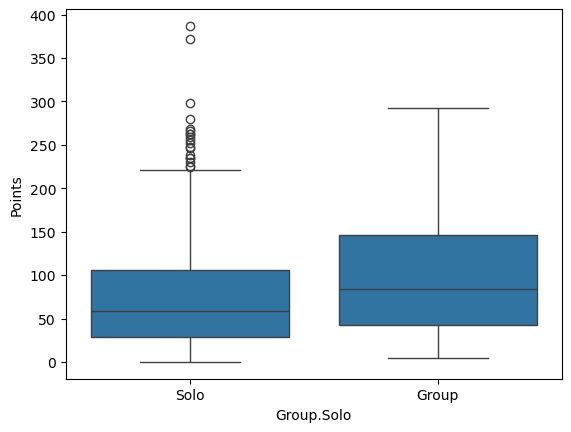

In [15]:
sns.boxplot(x='Group.Solo', y='Points', data=df)
plt.show()

In [16]:
features = ['Year', 'Artist.gender', 'Group.Solo', 'Song.In.English', 'energy', 'danceability', 'loudness', 'valence', 'tempo']
target = 'Points'

In [17]:
X = df[features]
y = df[target]

In [18]:
X.head()

,Year,Artist.gender,Group.Solo,Song.In.English,energy,danceability,loudness,valence,tempo
0,2009,Male,Solo,1,0.678258,0.598360,-9.082,0.482059,102.984
1,2009,Female,Group,1,0.794093,0.604542,-6.059,0.426209,105.972
2,2009,Female,Solo,0,0.574628,0.367344,-8.655,0.292870,124.005
3,2009,Female,Solo,1,0.672746,0.513202,-4.536,0.206493,128.021
4,2009,Both,Group,0,0.733959,0.590592,-4.427,0.344541,116.107


In [19]:
print(X.shape)
print(y.shape)

(648, 9)
(648,)


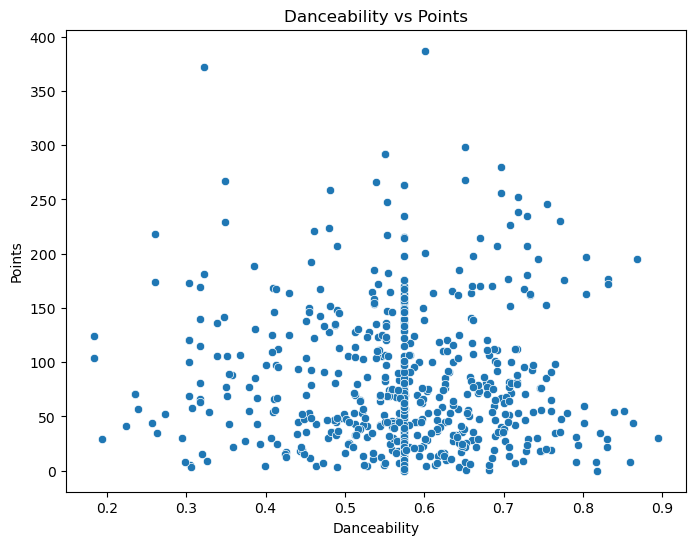

In [27]:
# Scatter plot between danceability and Points
plt.figure(figsize=(8, 6))
sns.scatterplot(x='danceability', y='Points', data=df)
plt.title('Danceability vs Points')
plt.xlabel('Danceability')
plt.ylabel('Points')
plt.show()

## Apparent Relationship & Hypothesis:
There appears to be a moderate positive correlation between danceability and points. Songs with higher danceability tend to score more points on average.
Hypothesis: Upbeat and energetic performances engage the audience and juries better, leading to higher voting scores in live music competitions like Eurovision.

In [28]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error
import joblib

In [29]:
# One-Hot Encoding for Categorical columns
X_encoded = pd.get_dummies(X, columns=['Artist.gender', 'Group.Solo', 'Song.In.English'], drop_first=True)

In [30]:
# Train-Test Split & Training
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

In [37]:
model = GradientBoostingRegressor(random_state=42)
model.fit(X_train, y_train)

,loss,'squared_error'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [38]:
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
print(f"Mean Absolute Error (MAE): {mae:.2f}")

Mean Absolute Error (MAE): 43.88


In [39]:
joblib.dump(model, 'eurovision_model.pkl')
joblib.dump(X_encoded.columns.tolist(), 'model_columns.pkl')

['model_columns.pkl']

##MAE Interpretation:The Mean Absolute Error (MAE) measures the average magnitude of prediction errors in terms of points. For example, an MAE of 20 means that, on average, the model's predicted points for a song deviate from the actual score by 20 points (either 20 points higher or lower).

In [41]:
import joblib
joblib.dump(model, r'C:\Users\user\Desktop\Calculator\eurovision_model.pkl')
joblib.dump(X_encoded.columns.tolist(), r'C:\Users\user\Desktop\Calculator\model_columns.pkl')

['C:\\Users\\user\\Desktop\\Calculator\\model_columns.pkl']